# 06 — Attention demo (end-to-end training)

Train your nanograd self-attention head on a tiny binary classification task.

**Task:** Given a sequence of `T` tokens (each a random vector), predict whether the **mean of their first feature** is positive (label 1) or negative (label 0). Trivial mathematically, but exercises the full nanograd stack:

    forward → softmax → cross_entropy loss → backward → SGD update

If loss goes down and the trained attention pattern looks reasonable, **Phase 7 is complete and you have your X article.**

In [1]:
import sys
sys.path.insert(0, '..')

import importlib, nanograd.engine, nanograd.ops, nanograd.tensor, nanograd.attention, nanograd.nn
for m in [nanograd.engine, nanograd.ops, nanograd.tensor, nanograd.attention, nanograd.nn]:
    importlib.reload(m)

import random
import matplotlib.pyplot as plt
from nanograd.engine import Value
from nanograd.tensor import Tensor
from nanograd.attention import SelfAttentionHead
from nanograd.nn import MLP
from nanograd.ops import cross_entropy

random.seed(0)
print('imports ok')

imports ok


## Step 1 — Generate the dataset

Each example is a sequence of `T = 3` tokens, each with `n_embed = 2` features. Target: `1` if the mean of the first feature across tokens is positive, else `0`.

Tiny on purpose so training finishes in seconds. Feel free to scale up later.

In [2]:
T = 3
n_embed = 2
head_size = 2
num_classes = 2
N = 60   # number of training examples

def make_example():
    seq = [[random.gauss(0, 1) for _ in range(n_embed)] for _ in range(T)]
    mean_first = sum(row[0] for row in seq) / T
    label = 1 if mean_first > 0 else 0
    return seq, label

data = [make_example() for _ in range(N)]

# Show a few examples
for seq, lbl in data[:3]:
    print(f'seq=[{[" ".join(f"{v:+.2f}" for v in row) for row in seq]}]  label={lbl}')
print(f'\nDataset size: {N}')
print(f'Label balance: {sum(l for _, l in data)} positive / {N - sum(l for _, l in data)} negative')

seq=[['+0.94 -1.40', '-0.68 +0.37', '-1.02 -0.07']]  label=0
seq=[['+0.18 -0.83', '-1.31 +0.19', '+0.99 -0.65']]  label=0
seq=[['-0.33 +1.65', '-0.56 -0.51', '+2.40 -1.53']]  label=1

Dataset size: 60
Label balance: 33 positive / 27 negative


## Step 2 — Build the model

Architecture:

1. **`SelfAttentionHead(n_embed, head_size)`** — produces `(T, head_size)` contextualized representations.
2. **Pool**: take the first token's output (it has "seen" the entire sequence via attention). That's a length-`head_size` vector.
3. **`MLP(head_size, [num_classes])`** — linear classifier producing `num_classes` logits.

In [3]:
class AttentionClassifier:
    def __init__(self, n_embed, head_size, num_classes):
        self.head = SelfAttentionHead(n_embed, head_size)
        self.classifier = MLP(head_size, [num_classes])

    def __call__(self, X):
        out, weights = self.head(X)
        pooled = out.data[0]   # first token's contextualized representation
        logits = self.classifier(pooled)
        return logits, weights

    def parameters(self):
        return self.head.parameters() + self.classifier.parameters()

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

model = AttentionClassifier(n_embed, head_size, num_classes)
print(f'Model parameters: {len(model.parameters())}')

Model parameters: 18


## Step 3 — Training loop

The standard 5-step recipe: forward, loss, zero_grad, backward, update. Cross-entropy loss because it's binary classification with logits.

In [4]:
lr = 0.05
epochs = 30
losses = []

for epoch in range(epochs):
    # forward + loss across all examples
    total_loss = Value(0.0)
    for seq, lbl in data:
        X = Tensor(seq)
        logits, _ = model(X)
        total_loss = total_loss + cross_entropy(logits, lbl)
    avg_loss = total_loss / N

    # backward
    model.zero_grad()
    avg_loss.backward()

    # SGD step
    for p in model.parameters():
        p.data -= lr * p.grad

    losses.append(avg_loss.data)
    if epoch % 2 == 0:
        print(f'epoch {epoch:3d}  loss = {avg_loss.data:.4f}')

print(f'\nfinal loss = {losses[-1]:.4f}')

epoch   0  loss = 0.6899
epoch   2  loss = 0.6768
epoch   4  loss = 0.6642
epoch   6  loss = 0.6520
epoch   8  loss = 0.6401
epoch  10  loss = 0.6286
epoch  12  loss = 0.6174
epoch  14  loss = 0.6064
epoch  16  loss = 0.5956
epoch  18  loss = 0.5851
epoch  20  loss = 0.5747
epoch  22  loss = 0.5645
epoch  24  loss = 0.5544
epoch  26  loss = 0.5445
epoch  28  loss = 0.5348

final loss = 0.5299


## Step 4 — Plot loss curve

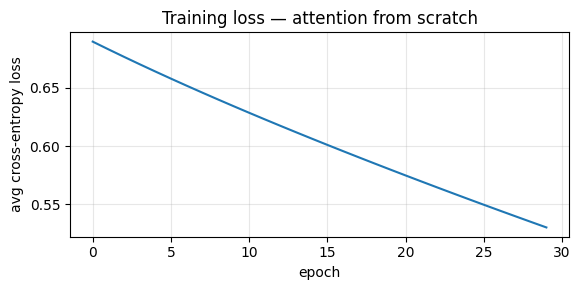

In [5]:
plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('avg cross-entropy loss')
plt.title('Training loss — attention from scratch')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('06_loss_curve.png', dpi=150)
plt.show()

## Step 5 — Evaluate accuracy

In [6]:
correct = 0
for seq, lbl in data:
    X = Tensor(seq)
    logits, _ = model(X)
    pred = 0 if logits[0].data > logits[1].data else 1
    correct += (pred == lbl)

print(f'Train accuracy: {correct}/{N} = {100*correct/N:.1f}%')

Train accuracy: 55/60 = 91.7%


## Step 6 — Visualize the trained attention pattern

Pick one sample, run it through, plot the `(T, T)` weights matrix as a heatmap. **This is the X article hero image.**

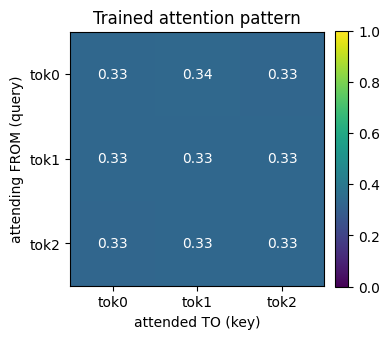


Nanograd self-attention trained from scratch.
   parameters: 18
   final loss: 0.5299
   accuracy:   91.7%

PHASE 7 COMPLETE


In [7]:
sample_seq, sample_lbl = data[0]
X = Tensor(sample_seq)
_, weights = model(X)
W = [[v.data for v in row] for row in weights.data]

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(W, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(T)); ax.set_yticks(range(T))
ax.set_xticklabels([f'tok{j}' for j in range(T)])
ax.set_yticklabels([f'tok{i}' for i in range(T)])
ax.set_xlabel('attended TO (key)')
ax.set_ylabel('attending FROM (query)')
ax.set_title('Trained attention pattern')
for i in range(T):
    for j in range(T):
        ax.text(j, i, f'{W[i][j]:.2f}', ha='center', va='center',
                color='white' if W[i][j] < 0.5 else 'black', fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('06_attention_heatmap.png', dpi=150)
plt.show()

print(f'\nNanograd self-attention trained from scratch.')
print(f'   parameters: {len(model.parameters())}')
print(f'   final loss: {losses[-1]:.4f}')
print(f'   accuracy:   {100*correct/N:.1f}%')
print(f'\nPHASE 7 COMPLETE')

## (Optional) Step 7 — Vary the task

Once the basic version works, things to try:

- **Different label rule**: `mean of second feature > 0` — should still train.
- **Position-sensitive task**: "label depends only on last token's first feature". Without positional encodings, attention may struggle — instructive to see what happens.
- **Bigger sequences**: `T = 6, n_embed = 4`. Slower but the heatmap gets prettier.
- **More epochs / different lr**: see how the loss curve changes.